# EMTA andmete analüüs

## Ettevalmistused

In [78]:
from typing import Callable

import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns

## Andmetega tutvumine

In [ ]:
# Pandas abil CSV-st andmete sisse lugemine
data_raw_this_year = pd.read_csv("tasutud_maksud_kaesolev_aasta.csv", nrows=5)
# data_raw_this_year.T # T transponeerib tabeli
data_raw_this_year

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,10.04.2026,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,1723565,2038192.0,2141341.0,...,1213643.0,1131417.0,34309154,30413704.0,23282177.0,21724706.0,254.0,243.0,244.0,240.0
1,10.04.2026,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2026,1561762,NaN,NaN,...,NaN,NaN,19993085,NaN,NaN,NaN,236.0,NaN,NaN,NaN
2,10.04.2026,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2025,40888,41980.0,38723.0,...,38979.0,36127.0,236677,235518.0,206299.0,280010.0,11.0,11.0,10.0,10.0
3,10.04.2026,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2026,48644,NaN,NaN,...,NaN,NaN,299247,NaN,NaN,NaN,11.0,NaN,NaN,NaN
4,10.04.2026,10000062,ALDO KOPPEL,FIE,Ida-Viru ( Lüganuse vald ),"PÕLLUMAJANDUS, METSAMAJANDUS JA KALAPÜÜK",2025,313,342.0,635.0,...,0.0,NaN,1941,2925.0,9273.0,906.0,NaN,NaN,NaN,NaN


In [ ]:
# DuckDB abil CSV-st andmete sisse lugemine
duckdb.sql("""
    FROM 'tasutud_maksud_varasemad_aastad.csv'
    LIMIT 5
""").df()

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),None,2022,<NA>,288,<NA>,...,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),None,2023,<NA>,288,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),None,2024,288,52,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,2026-04-10,01834575,"KUNDERI 24, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),None,2024,<NA>,<NA>,268,...,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2022,1300554,1645555,1185273,...,923188,950362,22930261,31976194,26140614,31599227,214,228,231,232


In [ ]:
# Kontrollime, kas tulpade nimed on mõlemas failis samad
data_raw_new = pd.read_csv("tasutud_maksud_kaesolev_aasta.csv", nrows=5)
data_raw_old = pd.read_csv("tasutud_maksud_varasemad_aastad.csv", nrows=5)
data_raw_new.columns == data_raw_old.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [19]:
# DuckDB abil mitmest CSV-st andmete sisse lugemine
data_raw = duckdb.sql("""
    FROM 'tasutud_maksud_kaesolev_aasta.csv'
    UNION ALL       
    FROM 'tasutud_maksud_varasemad_aastad.csv'
""").df()

In [27]:
# Liigutame erinevate kvartalite maksud eraldi ridadele
data_unpivot = duckdb.sql("""
    WITH base AS (
        SELECT
            "Andmete seis" AS andmete_seis,
            "Registrikood" AS registrikood,
            "Nimi" AS nimi,
            "Liik" AS liik,
            "Maakond" AS maakond,
            "Tegevusala" AS tegevusala,
            "Aasta" AS aasta,
            "Riiklikud maksud I kv" AS riiklikud_maksud_1,
            "Riiklikud maksud II kv" AS riiklikud_maksud_2,
            "Riiklikud maksud III kv" AS riiklikud_maksud_3,
            "Riiklikud maksud IV kv" AS riiklikud_maksud_4,
            "Tööjõumaksud I kv" AS toojou_maksud_1,
            "Tööjõumaksud II kv" AS toojou_maksud_2,
            "Tööjõumaksud III kv" AS toojou_maksud_3,
            "Tööjõumaksud IV kv" AS toojou_maksud_4,
            "Käive I kv" AS kaive_1,
            "Käive II kv" AS kaive_2,
            "Käive III kv" AS kaive_3,
            "Käive IV kv" AS kaive_4,
            "Töötajate arv I kv" AS tootajad_1,
            "Töötajate arv II kv" AS tootajad_2,
            "Töötajate arv III kv" AS tootajad_3,
            "Töötajate arv IV kv" AS tootajad_4
        FROM data_raw
    )
    UNPIVOT base
    ON
        (riiklikud_maksud_1, toojou_maksud_1, kaive_1, tootajad_1),
        (riiklikud_maksud_2, toojou_maksud_2, kaive_2, tootajad_2),
        (riiklikud_maksud_3, toojou_maksud_3, kaive_3, tootajad_3),
        (riiklikud_maksud_4, toojou_maksud_4, kaive_4, tootajad_4)
    INTO
        NAME kvartal
        VALUE riiklikud_maksud, toojoumaksud, kaive, tootajate_arv;
"""
).df()
data_unpivot[:5]

,andmete_seis,registrikood,nimi,liik,maakond,tegevusala,aasta,kvartal,riiklikud_maksud,toojoumaksud,kaive,tootajate_arv
0,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,riiklikud_maksud_1_toojou_maksud_1_kaive_1_too...,1723565,1259900,34309154,254
1,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,riiklikud_maksud_2_toojou_maksud_2_kaive_2_too...,2038192,1229742,30413704,243
2,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,riiklikud_maksud_3_toojou_maksud_3_kaive_3_too...,2141341,1213643,23282177,244
3,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,riiklikud_maksud_4_toojou_maksud_4_kaive_4_too...,1844403,1131417,21724706,240
4,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2026,riiklikud_maksud_1_toojou_maksud_1_kaive_1_too...,1561762,1088007,19993085,236


In [28]:
duckdb.sql("""
    SELECT distinct maakond
    FROM data_raw
""")

┌──────────────────────────────────┐
│             Maakond              │
│             varchar              │
├──────────────────────────────────┤
│ Jõgeva ( Jõgeva vald )           │
│ Tartu ( Luunja vald )            │
│ Viljandi ( Põhja-Sakala vald )   │
│ Harju ( Viimsi vald )            │
│ Harju ( Maardu linn )            │
│ Harju ( Kose vald )              │
│ Pärnu ( Häädemeeste vald )       │
│ Järva ( Türi vald )              │
│ Pärnu ( Põhja-Pärnumaa vald )    │
│ Valga ( Tõrva vald )             │
│          ·                       │
│          ·                       │
│          ·                       │
│ Harju ( Lääne-Harju vald )       │
│ Ida-Viru ( Kohtla-Järve linn )   │
│ Põlva ( Räpina vald )            │
│ Lääne ( Lääne-Nigula vald )      │
│ Põlva ( Kanepi vald )            │
│ Lääne-Viru ( Väike-Maarja vald ) │
│ Harju ( Rae vald )               │
│ Jõgeva ( Põltsamaa vald )        │
│ Tartu ( Kastre vald )            │
│ Pärnu ( Saarde vald )            │
├

In [116]:
def eralda_maakond(maakond: str) -> str:
    return maakond.split(" ( ")[0]

def eralda_kov(maakond: str) -> str:
    return maakond.split(" ( ")[1][:-2]
    #return maakond.split(" ( ")[1].replace(" )", "")

def eralda_kvartal(kvartal_string: str) -> int:
    return int(kvartal_string[-1])

def peamine_tegevusala(tegevusalad: str) -> str:
    return tegevusalad.split(";")[0]

def _register_duckdb_function(duckdb_function_name: str, function: Callable) -> None:
    try:
        duckdb.remove_function(duckdb_function_name)
    except:
        pass
    duckdb.create_function(duckdb_function_name, function)

# Kuidas öelda duckdb-le, et on defineeritud Pythoni funktsioon, mida saab SQL päringutes kasutada
_register_duckdb_function("eralda_maakond", eralda_maakond)
_register_duckdb_function("eralda_kov", eralda_kov)
_register_duckdb_function("eralda_kvartal", eralda_kvartal)
_register_duckdb_function("peamine_tegevusala", peamine_tegevusala)

In [75]:
print(eralda_kvartal("riiklikud_maksud_1_toojou_maksud_1_kaive_1_tootajad_1"))

1


In [117]:
data = duckdb.sql("""
    SELECT
        registrikood,
        nimi,
        liik,
        eralda_maakond(maakond) AS maakond,
        eralda_kov(maakond) AS kov,
        peamine_tegevusala(tegevusala) AS peamine_tegevusala,
        aasta,
        --cast(right(kvartal, 1) AS int) as kvartal_test,
        eralda_kvartal(kvartal) AS kvartal,
        riiklikud_maksud,
        toojoumaksud,
        kaive,
        tootajate_arv
    FROM data_unpivot
""").df()
data

,registrikood,nimi,liik,maakond,kov,peamine_tegevusala,aasta,kvartal,riiklikud_maksud,toojoumaksud,kaive,tootajate_arv
0,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,1,1723565,1259900,34309154,254
1,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,2,2038192,1229742,30413704,243
2,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,3,2141341,1213643,23282177,244
3,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,4,1844403,1131417,21724706,240
4,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2026,1,1561762,1088007,19993085,236
...,...,...,...,...,...,...,...,...,...,...,...,...
943929,QQ000003,RAUMASTER OY,Mitteresident,None,None,HULGI- JA JAEKAUBANDUS,2023,4,22804,23491,47353,4
943930,QQ000003,RAUMASTER OY,Mitteresident,None,None,HULGI- JA JAEKAUBANDUS,2024,1,31928,33059,99940,4
943931,QQ000003,RAUMASTER OY,Mitteresident,None,None,HULGI- JA JAEKAUBANDUS,2024,2,25677,26511,5551,4
943932,QQ000003,RAUMASTER OY,Mitteresident,None,None,HULGI- JA JAEKAUBANDUS,2024,3,27572,28496,0,4


## Avastuslik andmeanalüüs

In [86]:
duckdb.sql("""SUMMARIZE data""").df

<bound method pybind11_detail_function_record_v1_system_libcpp_abi1.df of ┌──────────────────┬─────────────┬──────────────────────────────────────────────────────────────┬────────────────────┬───────────────┬────────────────────┬────────────────────┬─────────┬─────────┬─────────┬────────┬─────────────────┐
│   column_name    │ column_type │                             min                              │        max         │ approx_unique │        avg         │        std         │   q25   │   q50   │   q75   │ count  │ null_percentage │
│     varchar      │   varchar   │                           varchar                            │      varchar       │     int64     │      varchar       │      varchar       │ varchar │ varchar │ varchar │ int64  │  decimal(9,2)   │
├──────────────────┼─────────────┼──────────────────────────────────────────────────────────────┼────────────────────┼───────────────┼────────────────────┼────────────────────┼─────────┼─────────┼─────────┼────────┼─────────

In [87]:
# palju on igas ettevõtte liigis ettevõtteid
duckdb.sql("""
    SELECT
        liik, 
        count(*) AS count
    FROM data
    GROUP BY liik
""").df()

,liik,count
0,Mittetulundusühing,9659
1,FIE,9753
2,Mitteresident,1128
3,Valitsus- ja riigiasutus,3729
4,Sihtasutus,3312
5,Äriühing,916353


In [89]:
duckdb.sql("""
    SELECT
        nimi, 
        kaive
    FROM data
    ORDER BY kaive DESC
    LIMIT 1
""").df()

,nimi,kaive
0,EESTI ENERGIA AS,1169920316


In [114]:
# palju on igas maakonnas ettevõtteid ja mis on keskmine kvartaalne käive
duckdb.sql("""
    SELECT
        maakond, 
        count(DISTINCT registrikood) AS ettevotete_arv,
        round(avg(kaive) / 3)::int as keskmine_kuine_kaive,
        round(avg(kaive))::int as keskmine_kvartaalne_kaive
    FROM data
    WHERE aasta = 2026 AND kvartal = 1
    GROUP BY maakond
    ORDER BY keskmine_kvartaalne_kaive desc
""").df()

,maakond,ettevotete_arv,keskmine_kuine_kaive,keskmine_kvartaalne_kaive
0,None,141,254183,762548
1,Harju,31202,201933,605799
2,Järva,936,124710,374131
3,Tartu,6616,120512,361536
4,Lääne-Viru,2095,105897,317690
5,Viljandi,1723,88801,266402
6,Valga,839,81555,244664
7,Jõgeva,949,80395,241184
8,Ida-Viru,2423,77621,232863
9,Pärnu,3536,72502,217507


In [110]:
# palju on igas maakonnas ettevõtteid ja mis on keskmine töötajate arv ning keskmine tööjõumaks
duckdb.sql("""
    SELECT
        maakond,
        count(DISTINCT registrikood) AS ettevotete_arv,
        round(avg(tootajate_arv), 2) as keskmine_tootajate_arv,
        round(avg(toojoumaksud), 2) as keskmine_toojoumaks
    FROM data
    WHERE aasta = 2026 AND kvartal = 1
    GROUP BY maakond
    ORDER BY keskmine_tootajate_arv desc
""").df()

,maakond,ettevotete_arv,keskmine_tootajate_arv,keskmine_toojoumaks
0,Harju,31202,10.38,40015.63
1,Tartu,6616,9.72,31882.52
2,Ida-Viru,2423,8.89,21393.44
3,Järva,936,8.45,23254.55
4,Lääne-Viru,2095,8.41,20247.05
5,Viljandi,1723,7.26,19457.30
6,Valga,839,6.90,17544.33
7,Võru,1259,6.90,15119.10
8,Saare,1358,6.84,17733.13
9,Pärnu,3536,6.78,17611.48


In [111]:
# palju on igas maakonnas ettevõtteid ja mis on keskmine töötajate arv ning keskmine tööjõumaks
duckdb.sql("""
    SELECT
        maakond,
        count(DISTINCT registrikood) AS ettevotete_arv,
        round(avg(kaive), 2) as keskmine_kaive,
        round(avg(tootajate_arv), 2) as keskmine_tootajate_arv,
        round(avg(riiklikud_maksud), 2) as keskmine_riiklik_maks
    FROM data
    WHERE aasta = 2026 AND kvartal = 1
    GROUP BY maakond
    ORDER BY keskmine_tootajate_arv desc
""").df()

,maakond,ettevotete_arv,keskmine_kaive,keskmine_tootajate_arv,keskmine_riiklik_maks
0,Harju,31202,605798.71,10.38,82933.94
1,Tartu,6616,361535.63,9.72,53765.51
2,Ida-Viru,2423,232862.59,8.89,32368.22
3,Järva,936,374130.57,8.45,37701.34
4,Lääne-Viru,2095,317690.28,8.41,40233.97
5,Viljandi,1723,266401.69,7.26,29334.60
6,Valga,839,244663.98,6.90,35717.94
7,Võru,1259,216442.95,6.90,24245.42
8,Saare,1358,187315.68,6.84,25136.96
9,Pärnu,3536,217507.37,6.78,29239.46


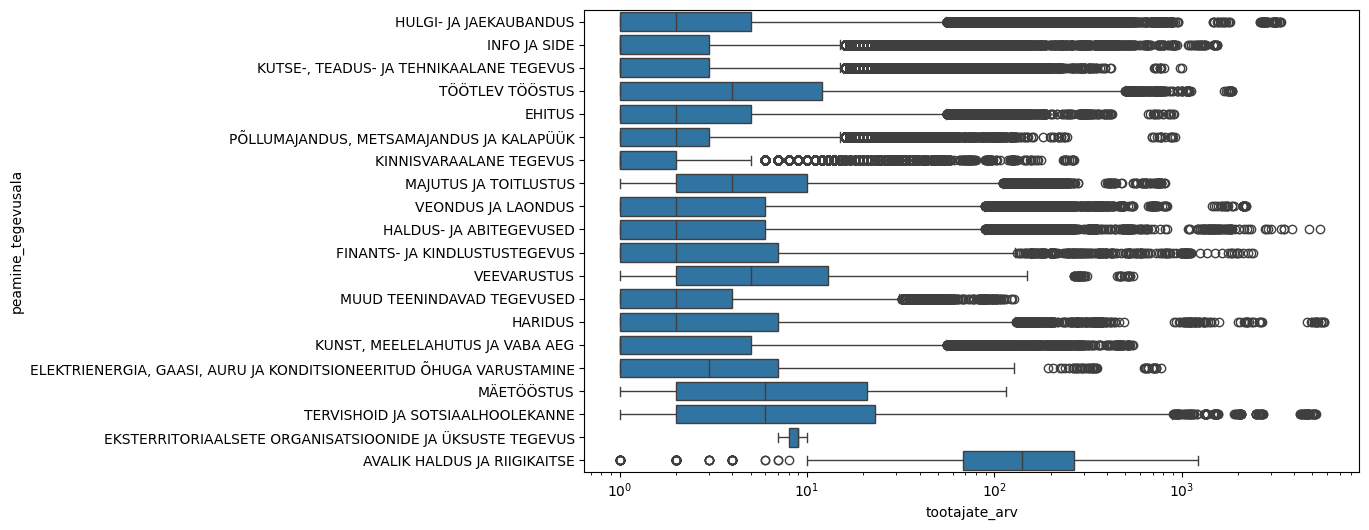

In [131]:
# box-plot, kus on ühel teljel kõik tegevusalad ja iga tegevusala kohta töötajate arv
# Eestis enamus ettevõtteid väikesed - alla 5 töötaja. Ehk seetõttu ei ole enamuse tegevusalade puhul "box" graafikul nähtav.
# Seetõttu töötajate arv teisendatud logaritmilisele skaalale.
plt.figure(1, figsize=(10, 6))
ax = sns.boxplot(data, x="tootajate_arv", y="peamine_tegevusala", log_scale=10)
# ax.set_xscale('log')
# Järeldus - enamusel tegevusaladel saab olla ettevõtte 1 töötajaga, va majutus ja toitlustus, veevarustus jne
# Kõige suuremad tööandja asuvad haldus- ja abitegevuste, hariduse, tervishoiu tegevusaladel

<Axes: xlabel='tootajate_arv', ylabel='peamine_tegevusala'>

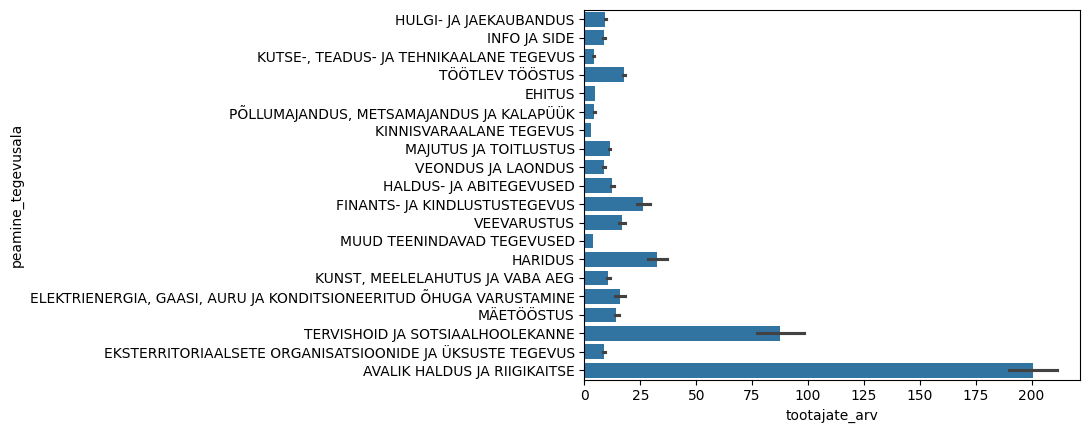

In [123]:
sns.barplot(data, x="tootajate_arv", y="peamine_tegevusala")

In [ ]:
# Kirjutame andmed CSV faili
data.to_csv("emta_data.csv", index=False)